### Modules used in this notebook
`pypsa`, `plotnine`
The notebook also requires a solver (e.g. `Cbc` or GLPK)

In [ ]:
import pandas as pd
dem = pd.read_parquet('../data/ERA5_full_demand_all_countries_2000_2019_hourly.parquet')
pv  = pd.read_parquet('../data/ERA5_solar_power_capacity_factor_all_countries_2000_2019_hourly.parquet')
win = pd.read_parquet('../data/ERA5_wind_power_capacity_factor_all_countries_2000_2019_inclusive.parquet')
dem.head()

,datetime,Austria,Belgium,Bulgaria,Croatia,Czech_Republic,Denmark,Finland,France,Germany,...,Norway,Poland,Portugal,Romania,Slovakia,Slovenia,Spain,Sweden,Switzerland,United_Kingdom
0,2000-01-01 00:00:00+00:00,6.149653,8.547436,4.288882,1.557109,6.583412,2.543370,10.218680,56.496736,40.287049,...,15.602364,15.173096,5.161892,6.074548,3.032983,1.177564,23.342019,16.258756,6.420162,31.481235
1,2000-01-01 01:00:00+00:00,6.005393,8.184474,4.241575,1.474065,6.535270,2.489337,10.133998,55.007324,39.336272,...,15.424182,14.849854,4.776771,6.029861,2.986461,1.152904,22.036881,16.147893,6.465112,29.741144
2,2000-01-01 02:00:00+00:00,5.854461,7.972377,4.265739,1.445917,6.463566,2.492441,10.185449,52.251049,39.381310,...,15.410204,14.818497,4.538195,6.085059,2.987110,1.149503,21.423310,16.162053,6.489145,27.999955
3,2000-01-01 03:00:00+00:00,5.945950,7.954598,4.407904,1.465845,6.551649,2.553254,10.472526,51.265385,40.223583,...,15.522155,15.023909,4.418843,6.265306,3.048357,1.170514,21.222722,16.324404,6.523057,27.066848
4,2000-01-01 04:00:00+00:00,6.444086,8.264821,4.780009,1.587208,6.891379,2.748628,11.128114,53.134412,42.170035,...,15.911743,15.634865,4.369596,6.687905,3.175566,1.260816,21.653859,16.956360,6.423579,26.070716


In [ ]:
selected_year = 2012 # 2000-2019
selected_month = 2 # 1 = January, 12 = December
country = 'Netherlands'

In [ ]:
# Select demand, solar (PV) and wind profiles
selected_dem = dem.loc[(pd.DatetimeIndex(dem['datetime']).year == selected_year) & (pd.DatetimeIndex(dem['datetime']).month == selected_month)][country]
selected_pv  = pv.loc[(pd.DatetimeIndex(pv['datetime']).year == selected_year) & (pd.DatetimeIndex(pv['datetime']).month == selected_month)][country]
selected_win = win.loc[(pd.DatetimeIndex(win['datetime']).year == selected_year) & (pd.DatetimeIndex(win['datetime']).month == selected_month)][country]

In [ ]:
selected_pv.loc[selected_pv < 0] = 0 

C:\Users\matte\AppData\Local\Temp\ipykernel_16284\392411492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_pv.loc[selected_pv < 0] = 0


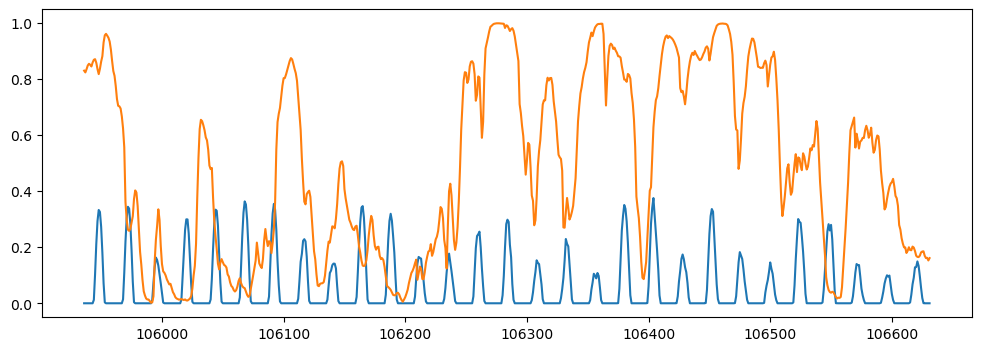

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 4))
plt.plot(selected_pv)
plt.plot(selected_win)
plt.show()

In [17]:
import pypsa

network = pypsa.Network(snapshots = selected_dem.index)
network.add("Bus", "B1")

network.add("Generator", "Wind",
            bus="B1",
            capital_cost = 3500,
            p_max_pu = selected_win,
            p_nom_extendable = True,
            control="PQ")

network.add("Generator", "Solar",
            bus="B1",
            capital_cost = 2000,
            p_max_pu = selected_pv,
            p_nom_extendable = True,
            control="PQ")

network.add("StorageUnit", "Battery",
            bus="B1",
            capital_cost = 4500,
            marginal_cost = 0.01,
            efficiency_store = 0.9,
            efficiency_dispatch = 0.9,
            max_hours = 3,
            p_nom_extendable = True
            )

config = 'voll' # 'none', 'voll', 'elastic', 'pwl'

if config == 'voll':
    network.add(
        "Generator",
        "load-shedding",
        bus="B1",
        carrier="load",
        marginal_cost=200,
        p_nom=100,
    )
elif config == 'elastic':
    network.add(
            "Generator",
            "load-shedding",
            bus="B1",
            carrier="load",
            marginal_cost_quadratic=2000 / (2 * 100),
            p_nom=100,
        )



# PWL
# network.add(
#                 "Generator",
#                 f"load-shedding-segment-{0}",
#                 bus="B1",
#                 carrier="load",
#                 marginal_cost=8000 - 80 * 95,
#                 marginal_cost_quadratic=80 / 2,
#                 p_nom=95,
#             )
# network.add(
#                 "Generator",
#                 f"load-shedding-segment-{1}",
#                 bus="B1",
#                 carrier="load",
#                 marginal_cost=400 - 40 * 5,
#                 marginal_cost_quadratic=40 / 2,
#                 p_nom=5,
#             )
# network.add(
#                 "Generator",
#                 f"load-shedding-segment-{2}",
#                 bus="B1",
#                 carrier="load",
#                 marginal_cost=200 - 20 * 10,
#                 marginal_cost_quadratic=20 / 2,
#                 p_nom=10,
#             )
network.add("Load", "L1",
            bus="B1",
            p_set=100
            )

network.optimize(network.snapshots, solver_name='gurobi')

Index(['B1'], dtype='object', name='Bus')
Index(['load-shedding'], dtype='object', name='Generator')
Index(['B1'], dtype='object', name='Bus')
Index(['load-shedding'], dtype='object', name='Generator')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2026-01-02


INFO:gurobipy:Academic license - for non-commercial use only - expires 2026-01-02
INFO:linopy.io: Writing time: 0.14s


...

Solved in 1262 iterations and 0.07 seconds (0.08 work units)


INFO:gurobipy:Solved in 1262 iterations and 0.07 seconds (0.08 work units)


Optimal objective  3.663268325e+06


INFO:gurobipy:Optimal objective  3.663268325e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 4179 primals, 9747 duals
Objective: 3.66e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [18]:
# BASE W 811 S 121 Sto 106 -  3.56e+06
# VOLL W 622 S 117 Sto 165 - 3.39e+06
# ELA W 428 S 155 Sto 130 - 2.73e+06
# PWL W 350 S 172 Sto 161 - 2.57e+06
print(network.statistics.expanded_capacity())
print(network.generators.p_nom_opt)

component    carrier
Generator    -          599.72571
             load         0.00000
StorageUnit  -           27.01107
dtype: float64
Generator
Wind             488.413026
Solar            111.312680
load-shedding    100.000000
Name: p_nom_opt, dtype: float64


# Step 06: Plotting the dispatching
To plot the generation of the three assets modeled in this example we need to insert the data contained in the `network` object into a Pandas data frame. This is eventually used for a plot made with [plotnine](https://plotnine.readthedocs.io/en/stable/)

In [20]:
gen_list = network.generators[['bus']].reset_index()
gen_list['type'] = gen_list['Generator'].str.split('_', expand = True).iloc[:,0]
gen = (pd.merge(
    network.generators_t.p
    .unstack()
    .reset_index(), gen_list)
       .groupby(['type', 'bus', 'snapshot'])
       .sum()
       .reset_index()
      ).rename(columns = {0: 'prod'})

sto_list = network.storage_units[['bus']].reset_index()
sto_list['type'] = sto_list['StorageUnit'].str.split('_', expand = True).iloc[:,0]
sto = (pd.merge(
    network.storage_units_t.p
    .unstack()
    .reset_index(), sto_list)
       .groupby(['type', 'bus', 'snapshot'])
       .sum().reset_index()
      ).rename(columns = {0: 'prod'})

df = pd.concat([gen, sto])
df.head()

,type,bus,snapshot,Generator,prod,StorageUnit
0,Solar,B1,105936,Solar,0.0,NaN
1,Solar,B1,105937,Solar,0.0,NaN
2,Solar,B1,105938,Solar,0.0,NaN
3,Solar,B1,105939,Solar,0.0,NaN
4,Solar,B1,105940,Solar,0.0,NaN


INFO:matplotlib.font_manager:Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


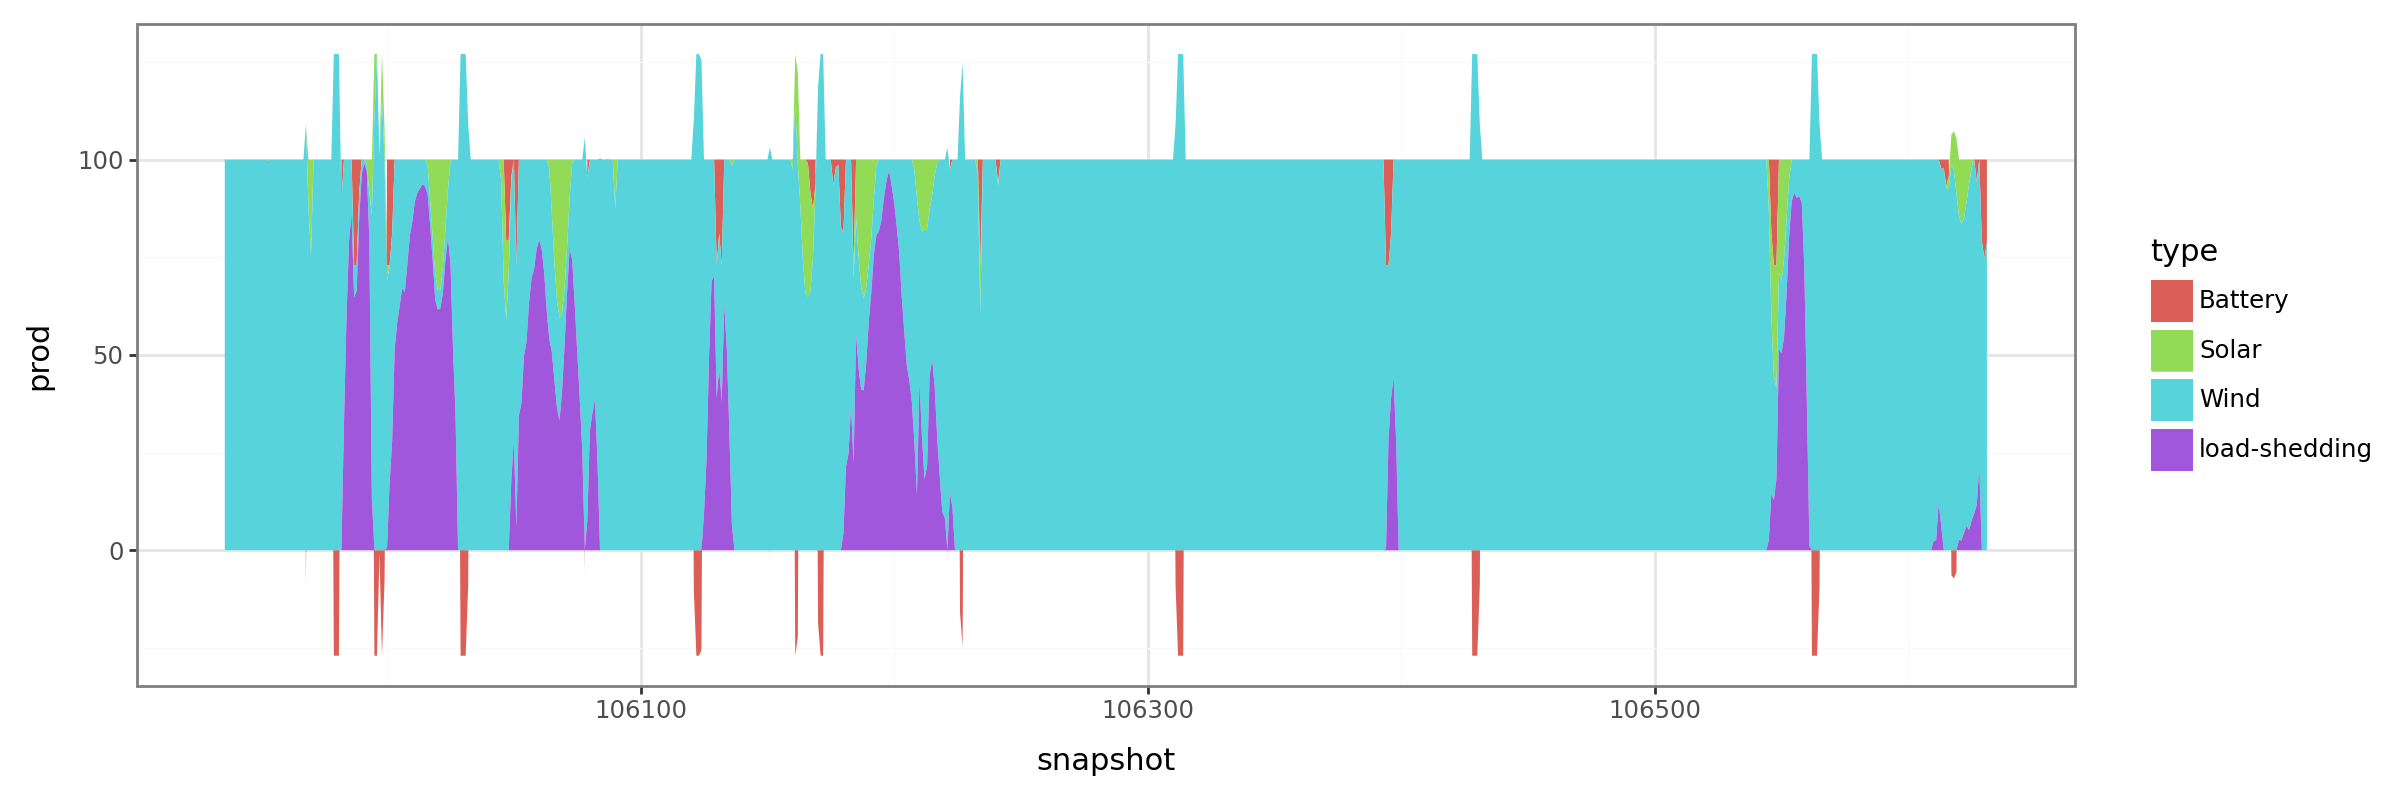

In [21]:
import plotnine
plotnine.options.figure_size = (12, 4)

(
    # plotnine.ggplot(pd.DataFrame(network.loads_t.p_set.L1).reset_index(), plotnine.aes(x='snapshot', y='L1')) +
    plotnine.ggplot() +
    plotnine.geom_area(plotnine.aes(x = 'snapshot', y = 'prod', fill = 'type'), data= df) +
    # plotnine.geom_line() +
    plotnine.theme_bw()
)

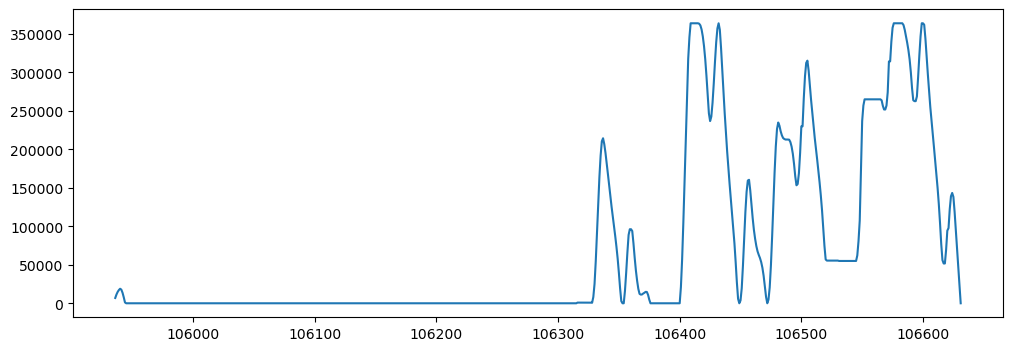

In [21]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 4))
plt.plot(network.storage_units_t.state_of_charge)
plt.show()